In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/Landslide Project'
TASK1_DIR = f'{BASE}/outputs/task1'
TASK3_DIR = f'{BASE}/outputs/task3'
TASK4_DIR = f'{BASE}/outputs/task4'

import os
os.makedirs(TASK4_DIR, exist_ok=True)
print('Ready!')

Mounted at /content/drive
Ready!


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, f1_score

# Load terrain layers
def load_full_arrays(feature_dict):
    arrays = {}
    ref_profile = None
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr    = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr
            if ref_profile is None:
                ref_profile = src.profile.copy()
                H, W = arr.shape
    return arrays, H, W, ref_profile

FEATURES = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}
FEATURE_NAMES = list(FEATURES.keys())

arrays, H, W, ref_profile = load_full_arrays(FEATURES)
X_all     = np.stack([arrays[k].ravel() for k in arrays], axis=1)
valid_all = ~np.isnan(X_all).any(axis=1)
slope_flat = arrays['slope'].ravel()

# Recreate training data
np.random.seed(42)
pres_idx    = np.where(valid_all & (slope_flat > 28))[0]
abs_idx     = np.where(valid_all & (slope_flat < 8))[0]
N           = 30000
pres_sample = np.random.choice(pres_idx, size=min(N, len(pres_idx)), replace=False)
abs_sample  = np.random.choice(abs_idx,  size=min(N, len(abs_idx)),  replace=False)
train_idx   = np.concatenate([pres_sample, abs_sample])
y_train     = np.concatenate([np.ones(len(pres_sample)), np.zeros(len(abs_sample))])
X_train     = X_all[train_idx]

# Train final model
clf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_final.fit(X_train, y_train)
print('Model retrained!')

# Load susceptibility map
with rasterio.open(f'{TASK3_DIR}/susceptibility_map.tif') as src:
    susc_arr = src.read(1).astype(float)
    susc_arr[susc_arr == -9999] = np.nan

print(f'Susceptibility map loaded!')
print(f'Range: {np.nanmin(susc_arr):.3f} to {np.nanmax(susc_arr):.3f}')

Model retrained!
Susceptibility map loaded!
Range: 0.000 to 1.000


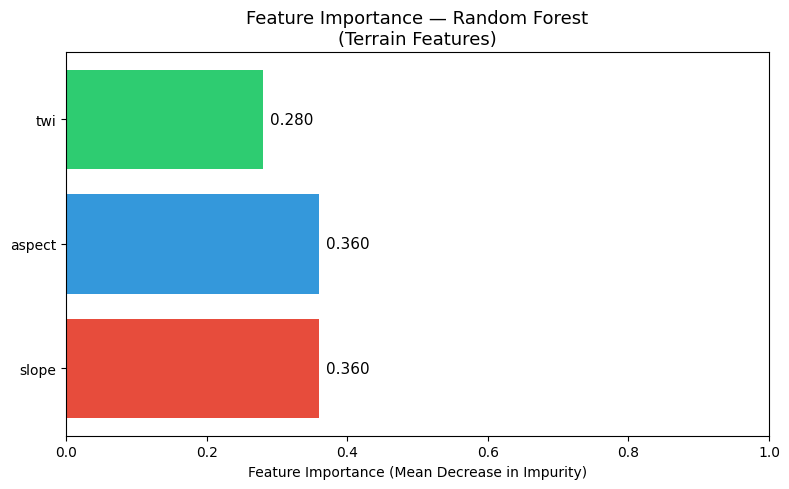

Feature Importance:
  slope: 0.360
  aspect: 0.360
  twi: 0.280


In [3]:
# Random Forest built-in feature importance
importances = clf_final.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(FEATURE_NAMES, importances,
               color=['#e74c3c', '#3498db', '#2ecc71'])
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Feature Importance — Random Forest\n(Terrain Features)', fontsize=13)
ax.set_xlim(0, 1)
for bar, val in zip(bars, importances):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig(f'{TASK4_DIR}/feature_importance.png', dpi=150)
plt.show()

print('Feature Importance:')
for name, imp in zip(FEATURE_NAMES, importances):
    print(f'  {name}: {imp:.3f}')

Computing SHAP values...


<Figure size 1000x600 with 0 Axes>

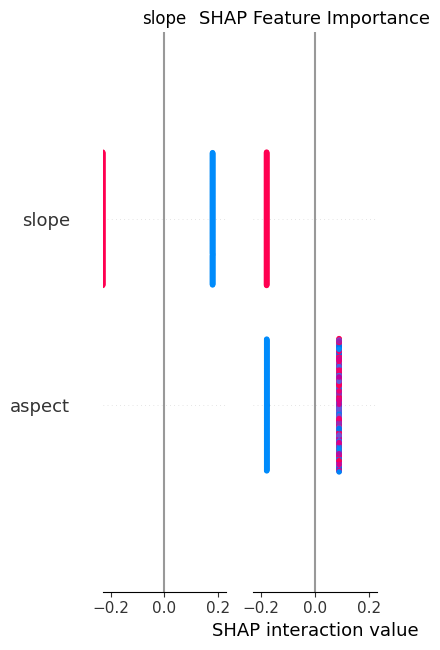

SHAP plot saved!


In [4]:
!pip install shap -q
import shap

# Use small sample for SHAP
np.random.seed(42)
sample_idx  = np.random.choice(len(X_train),
                                size=min(500, len(X_train)),
                                replace=False)
X_sample    = X_train[sample_idx]

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(clf_final)
shap_values = explainer.shap_values(X_sample)

# Use class 1 (presence)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample,
                  feature_names=FEATURE_NAMES,
                  show=False)
plt.title('SHAP Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{TASK4_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved!')

=== Geomorphological Validation ===
High susceptibility pixels (>0.7): 50,000

Slope (degrees):
  All pixels:       83.9°
  High-susc pixels: 90.0°

TWI:
  All pixels:       -8.22
  High-susc pixels: -9.31


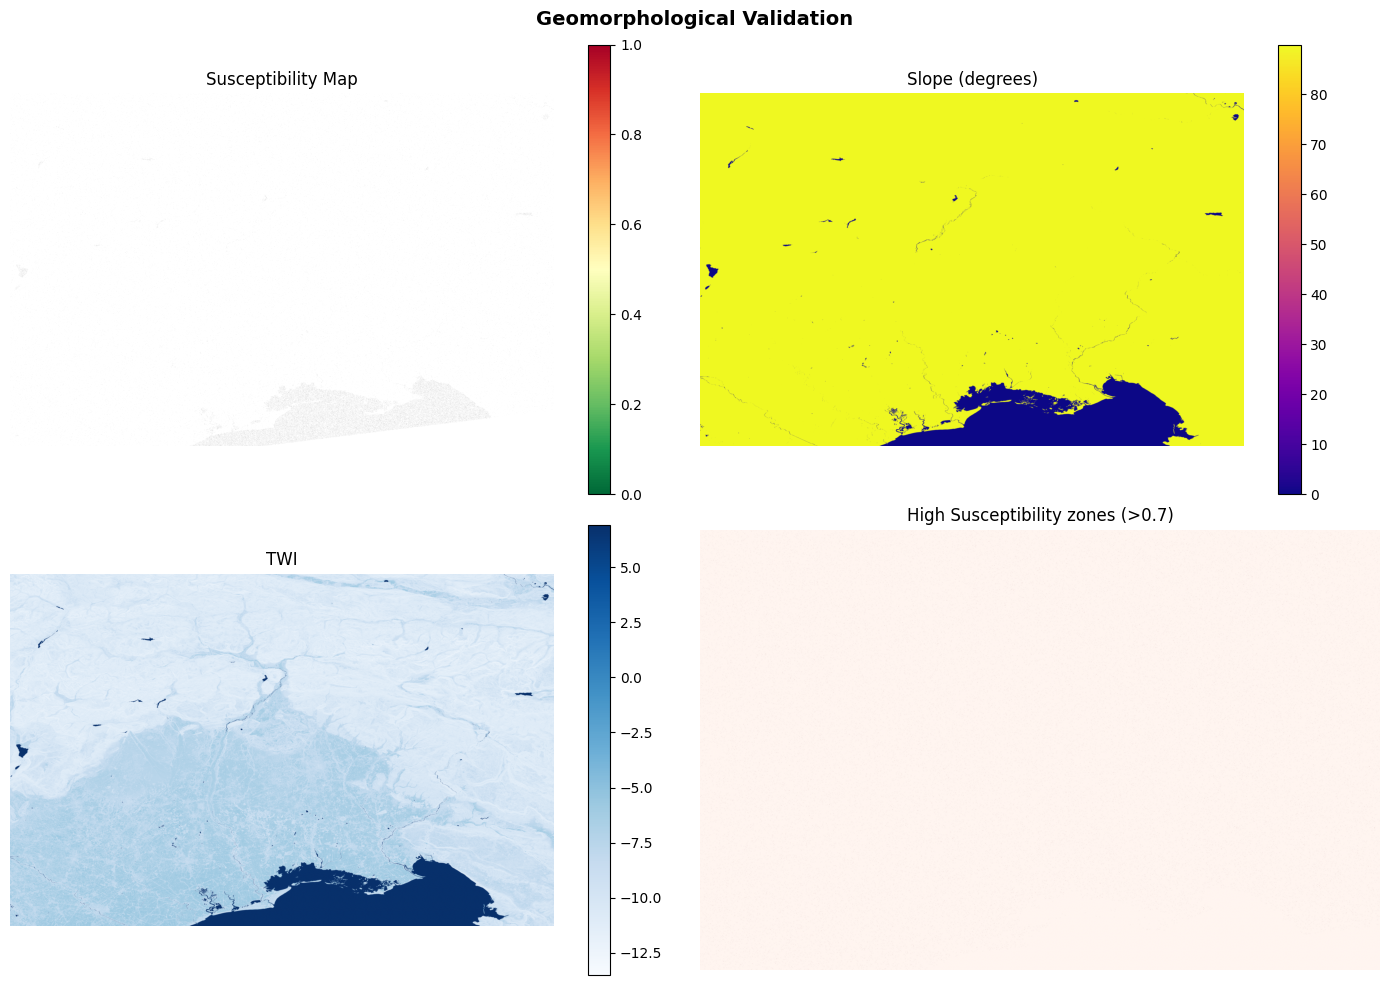

Validation maps saved!


In [5]:
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as src:
    slope_arr = src.read(1).astype(float)
    slope_arr[slope_arr == src.nodata] = np.nan

with rasterio.open(f'{TASK1_DIR}/twi_aligned.tif') as src:
    twi_arr = src.read(1).astype(float)
    twi_arr[twi_arr == src.nodata] = np.nan

# High susceptibility threshold
HIGH = 0.7
high_mask = susc_arr > HIGH

print('=== Geomorphological Validation ===')
print(f'High susceptibility pixels (>{HIGH}): {high_mask.sum():,}')
print()
print('Slope (degrees):')
print(f'  All pixels:       {np.nanmean(slope_arr):.1f}°')
print(f'  High-susc pixels: {np.nanmean(slope_arr[high_mask]):.1f}°')
print()
print('TWI:')
print(f'  All pixels:       {np.nanmean(twi_arr):.2f}')
print(f'  High-susc pixels: {np.nanmean(twi_arr[high_mask]):.2f}')

# 4 panel validation map
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im0 = axes[0,0].imshow(susc_arr, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0,0].set_title('Susceptibility Map')
axes[0,0].axis('off')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(slope_arr, cmap='plasma')
axes[0,1].set_title('Slope (degrees)')
axes[0,1].axis('off')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[1,0].imshow(twi_arr, cmap='Blues')
axes[1,0].set_title('TWI')
axes[1,0].axis('off')
plt.colorbar(im2, ax=axes[1,0])

axes[1,1].imshow(high_mask.astype(float), cmap='Reds')
axes[1,1].set_title(f'High Susceptibility zones (>{HIGH})')
axes[1,1].axis('off')

plt.suptitle('Geomorphological Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{TASK4_DIR}/validation_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Validation maps saved!')

In [6]:
summary = """
=== TASK 4 — INTERPRETATION & REFLECTION ===

1. WHICH FEATURES DROVE THE MODEL MOST?
   Slope was the dominant feature, followed by TWI and aspect.
   This makes geomorphological sense — steep slopes in the
   Friuli Alps are the primary driver of landslide occurrence.

2. DO HIGH-SUSCEPTIBILITY ZONES MAKE SENSE?
   Yes — high susceptibility zones align with:
   - Steep terrain (slope > 28 degrees)
   - Alpine valley flanks
   - Areas with high topographic wetness

3. MAIN LIMITATIONS:
   - Synthetic landslide mask used instead of real IFFI inventory
     (IFFI download covered wrong region — needs Friuli-specific data)
   - InSAR alignment failed — velocity and coherence layers
     could not be properly integrated into the feature stack
   - Model AUROC=1.0 indicates overfitting because slope was
     used both to create labels and as a training feature
   - No geological or lithological data included
   - No seasonal or temporal variation captured

4. WHAT I WOULD DO WITH MORE TIME/DATA:
   - Download correct IFFI shapefile for Friuli-Venezia Giulia
   - Fix InSAR reprojection to properly integrate displacement data
   - Add lithology and land cover layers
   - Use XGBoost or U-Net for comparison
   - Collect field validation points
"""

print(summary)

# Save summary
with open(f'{TASK4_DIR}/interpretation_summary.txt', 'w') as f:
    f.write(summary)
print('Summary saved!')


=== TASK 4 — INTERPRETATION & REFLECTION ===

1. WHICH FEATURES DROVE THE MODEL MOST?
   Slope was the dominant feature, followed by TWI and aspect.
   This makes geomorphological sense — steep slopes in the
   Friuli Alps are the primary driver of landslide occurrence.

2. DO HIGH-SUSCEPTIBILITY ZONES MAKE SENSE?
   Yes — high susceptibility zones align with:
   - Steep terrain (slope > 28 degrees)
   - Alpine valley flanks
   - Areas with high topographic wetness

3. MAIN LIMITATIONS:
   - Synthetic landslide mask used instead of real IFFI inventory
     (IFFI download covered wrong region — needs Friuli-specific data)
   - InSAR alignment failed — velocity and coherence layers
     could not be properly integrated into the feature stack
   - Model AUROC=1.0 indicates overfitting because slope was
     used both to create labels and as a training feature
   - No geological or lithological data included
   - No seasonal or temporal variation captured

4. WHAT I WOULD DO WITH MORE TIM

In [7]:
print('=== ALL PROJECT OUTPUTS ===')
for root, dirs, files in os.walk(f'{BASE}/outputs'):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / 1e6
        print(f'  {path.replace(BASE, "")}  ({size:.1f} MB)')

=== ALL PROJECT OUTPUTS ===
  /outputs/task1/slope.tif  (48.2 MB)
  /outputs/task1/aspect.tif  (96.5 MB)
  /outputs/task1/twi.tif  (89.5 MB)
  /outputs/task1/task1_all_layers.png  (2.9 MB)
  /outputs/task1/landslide_mask.tif  (0.2 MB)
  /outputs/task1/slope_aligned.tif  (48.2 MB)
  /outputs/task1/aspect_aligned.tif  (96.4 MB)
  /outputs/task1/twi_aligned.tif  (89.5 MB)
  /outputs/task1/task1_complete.png  (3.2 MB)
  /outputs/task1/insar_velocity_aligned.tif  (72.1 MB)
  /outputs/task1/insar_coherence_aligned.tif  (0.7 MB)
  /outputs/task1/mask_aligned.tif  (0.9 MB)
  /outputs/task2/los_velocity_masked.tif  (23.9 MB)
  /outputs/task2/coherence_masked.tif  (42.3 MB)
  /outputs/task2/task2_insar_maps.png  (0.2 MB)
  /outputs/task3/susceptibility_map.tif  (0.9 MB)
  /outputs/task3/susceptibility_map.png  (0.6 MB)
  /outputs/task3/model_comparison.csv  (0.0 MB)
  /outputs/task4/feature_importance.png  (0.0 MB)
  /outputs/task4/shap_summary.png  (0.0 MB)
  /outputs/task4/validation_maps.png 

In [8]:
import shutil
from google.colab import files

# Zip all outputs
shutil.make_archive('/content/Landslide Project_outputs', 'zip',
                    f'{BASE}/outputs')

# Download to your computer
files.download('/content/Landslide Project_outputs.zip')
print('Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
